In [19]:
# ==============================================================================
# CELL 1: CORE FOUNDATION, DATA ARCHITECTURE & GLOBAL CONFIGURATION
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 1: Loading Dataset ---")
df = pd.read_csv("Cleaned_Topic3_healthcare_analytics_dataset.csv")
print(f"Dataset securely loaded. Total observations: {df.shape[0]} rows.")

print("\n--- Step 2: Global Feature Configuration ---")
# DEFINING GLOBAL LISTS: By defining these once here, future functions (like your
# interactive controllers) can just reference these lists instead of us re-typing them.
TARGET_VAR = 'Stay'

CATEGORICAL_FEATURES = [
    'Hospital_type_code', 'Hospital_region_code', 'Department',
    'Ward_Type', 'Ward_Facility_Code', 'Type of Admission',
    'Severity of Illness', 'Age', 'Bed Grade'
]

CONTINUOUS_FEATURES = [
    'Admission_Deposit',
    'Visitors with Patient',
    'Available Extra Rooms in Hospital'
]

print("Global feature lists established.")

print("\n--- Step 3: Categorical Axis Ordering ---")
# Explicit hierarchies to force chronological/logical alignment on graphs
stay_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', 'More than 100 Days']
age_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']
severity_order = ['Minor', 'Moderate', 'Extreme']
admission_order = ['Emergency', 'Urgent', 'Trauma']

# Auto-sorting the alphabetical categories
hospital_type_order = sorted(df['Hospital_type_code'].unique())
region_order = sorted(df['Hospital_region_code'].unique())
dept_order = sorted(df['Department'].unique())
ward_order = sorted(df['Ward_Type'].unique())
facility_order = sorted(df['Ward_Facility_Code'].unique())

# Safely reconfigure EVERY text column into an ordered categorical block
df['Stay'] = pd.Categorical(df['Stay'], categories=stay_order, ordered=True)
df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)
df['Severity of Illness'] = pd.Categorical(df['Severity of Illness'], categories=severity_order, ordered=True)
df['Type of Admission'] = pd.Categorical(df['Type of Admission'], categories=admission_order, ordered=True)
df['Hospital_type_code'] = pd.Categorical(df['Hospital_type_code'], categories=hospital_type_order, ordered=True)
df['Hospital_region_code'] = pd.Categorical(df['Hospital_region_code'], categories=region_order, ordered=True)
df['Department'] = pd.Categorical(df['Department'], categories=dept_order, ordered=True)
df['Ward_Type'] = pd.Categorical(df['Ward_Type'], categories=ward_order, ordered=True)
df['Ward_Facility_Code'] = pd.Categorical(df['Ward_Facility_Code'], categories=facility_order, ordered=True)

print("Categorical axes successfully mapped.")

print("\n--- Step 4: Pre-calculating Universal Data Transformations ---")
# DRY PRINCIPLE: We calculate the Numeric Rank for Stay here ONCE.
# Cell 3 (Second-Order Heatmaps) needs this math, but by doing it here globally,
# we never have to type out or calculate this transformation again in any future cell.
df['Stay_Numeric_Rank'] = df['Stay'].cat.codes

print("Foundation complete. The dataset is optimized and ready for modular functions.")

--- Step 1: Loading Dataset ---
Dataset securely loaded. Total observations: 313793 rows.

--- Step 2: Global Feature Configuration ---
Global feature lists established.

--- Step 3: Categorical Axis Ordering ---
Categorical axes successfully mapped.

--- Step 4: Pre-calculating Universal Data Transformations ---
Foundation complete. The dataset is optimized and ready for modular functions.


In [30]:
# ==============================================================================
# CELL 2 (UPGRADED): THE RENDERING ENGINES WITH AUTOMATED STATISTICAL CONTEXT
# ==============================================================================

# Defensive check: Ensure Cell 1 was executed first [Certain]
if 'CATEGORICAL_FEATURES' not in globals():
    raise RuntimeError("❌ Global features missing. You must run Cell 1 first.")

def render_first_order_plot(dataframe, column_name):
    """
    Core engine for First-Order Stacked Bar Charts.
    Includes automated binning and raw statistical matrix output.
    """
    plot_data = dataframe.copy()

    if column_name in CONTINUOUS_FEATURES:
        if column_name == 'Admission_Deposit':
            plot_data[column_name] = pd.qcut(dataframe[column_name], q=5, duplicates='drop').astype(str)
        elif column_name == 'Visitors with Patient':
            plot_data[column_name] = pd.cut(dataframe[column_name], bins=[-1, 2, 4, 6, 10, 100],
                                            labels=['0-2 Visitors', '3-4 Visitors', '5-6 Visitors', '7-10 Visitors', '10+ Visitors']).astype(str)
        elif column_name == 'Available Extra Rooms in Hospital':
            plot_data[column_name] = pd.cut(dataframe[column_name], bins=[-1, 1, 3, 5, 25],
                                            labels=['0-1 Rooms', '2-3 Rooms', '4-5 Rooms', '6+ Rooms']).astype(str)

    crosstab = pd.crosstab(plot_data[column_name], plot_data[TARGET_VAR])
    crosstab_normalized = crosstab.div(crosstab.sum(1), axis=0)

    plt.figure(figsize=(14, 6))
    crosstab_normalized.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black', ax=plt.gca())

    plt.title(f"First-Order Correlation: Stay Proportions by '{column_name}'", fontsize=14, fontweight='bold')
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel("Proportion of Patients (Normalized)", fontsize=12)
    plt.legend(title="Stay Duration (Days)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- INJECTED MATHEMATICAL CONTEXT ---
    print("\n" + "="*80)
    print(f"STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on '{column_name}'")
    print("="*80)
    # Multiply by 100 to convert from 0.0-1.0 to cleaner percentages for the viewer [Certain]
    print((crosstab_normalized * 100).round(2).to_string())
    print("="*80 + "\n")


def render_second_order_heatmap(dataframe, metric_a, metric_b):
    """
    Core engine for Second-Order Interaction Matrices.
    Includes the raw mathematical pivot table output.
    """
    if metric_a == metric_b:
        print(f"⚠️ Skipping matrix: '{metric_a}' cannot be cross-referenced with itself.")
        return

    pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()

    plt.figure(figsize=(12, 7))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={'label': 'Mean Stay Rank (Darker = Longer Stay)'})

    plt.title(f"Second-Order Matrix: Interaction of {metric_a} & {metric_b}", fontsize=14, fontweight='bold')
    plt.xlabel(metric_b, fontsize=12)
    plt.ylabel(metric_a, fontsize=12)
    plt.tight_layout()
    plt.show()

    # --- INJECTED MATHEMATICAL CONTEXT ---
    print("\n" + "="*80)
    print(f"STATISTICAL MATRIX: Mean Stay Rank for '{metric_a}' combined with '{metric_b}'")
    print("Note: Ranks range from 0 (0-10 Days) to 10 (More than 100 Days).")
    print("="*80)
    print(pivot_table.round(2).to_string())
    print("="*80 + "\n")


def render_median_trendline(dataframe, continuous_metric):
    """
    Core engine for Continuous Metric Trend Lines.
    Outputs the hard numerical medians across the duration brackets.
    """
    plt.figure(figsize=(14, 6))
    sns.lineplot(x=TARGET_VAR, y=continuous_metric, data=dataframe,
                 estimator='median', errorbar=None, marker='o',
                 linewidth=3, markersize=10, color='darkred')

    plt.title(f"Median Trend: {continuous_metric} across Stay Durations", fontsize=14, fontweight='bold')
    plt.xlabel("Length of Stay (Days)", fontsize=12)
    plt.ylabel(f"Median {continuous_metric}", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- INJECTED MATHEMATICAL CONTEXT ---
    print("\n" + "="*80)
    print(f"STATISTICAL MATRIX: Exact Median '{continuous_metric}' for each Stay category")
    print("="*80)
    # Calculate the exact median for each category and structure it cleanly [Certain]
    stats_df = dataframe.groupby(TARGET_VAR)[continuous_metric].median().reset_index()
    print(stats_df.to_string(index=False))
    print("="*80 + "\n")

print("Upgraded rendering engines loaded. Statistical matrices will now print automatically.")

Upgraded rendering engines loaded. Statistical matrices will now print automatically.


🔄 Starting batch generation for 9 first-order plots...



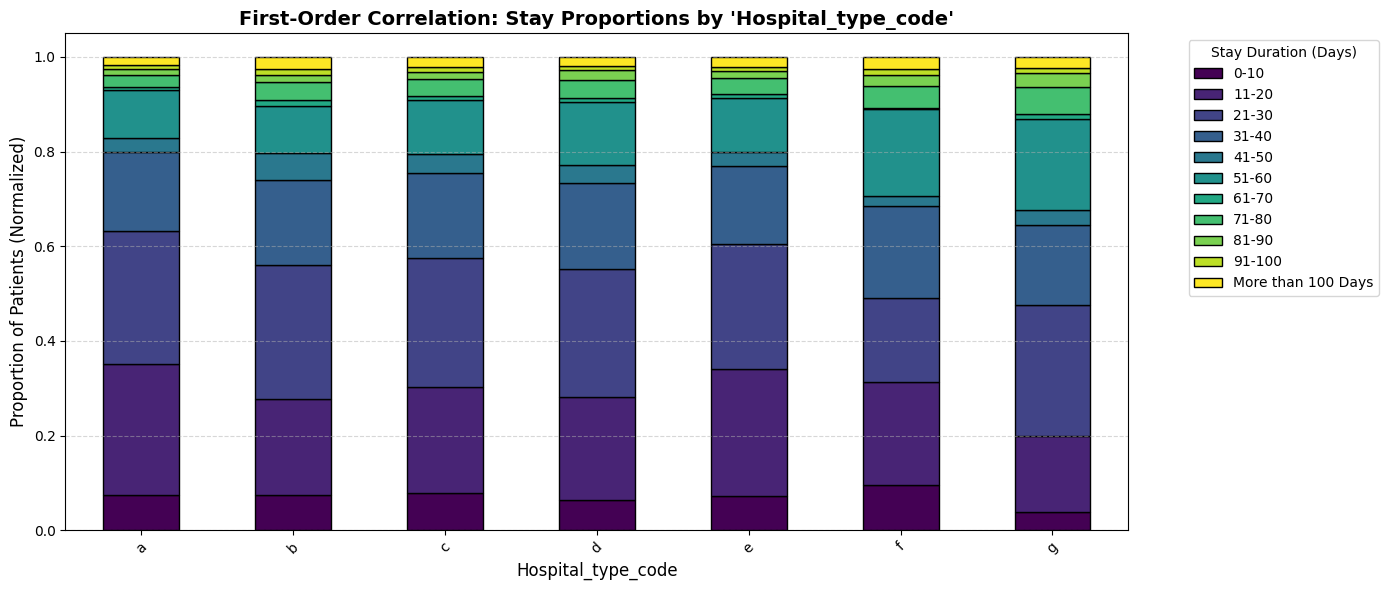


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Hospital_type_code'
Stay                0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Hospital_type_code                                                                                          
a                   7.38  27.81  28.11  16.68   2.85  10.16   0.64   2.59   1.32    0.67                1.78
b                   7.44  20.22  28.37  17.98   5.61  10.02   1.33   3.79   1.49    1.14                2.61
c                   7.79  22.49  27.30  17.91   4.08  11.28   0.93   3.49   1.58    0.95                2.19
d                   6.43  21.74  27.13  18.17   3.74  13.30   0.91   3.70   2.04    0.87                1.96
e                   7.27  26.84  26.46  16.33   3.08  11.37   0.79   3.36   1.58    0.89                2.03
f                   9.54  21.83  17.76  19.49   1.92  18.39   0.41   4.47   2.35    1.28                2.58
g                   3.92  16.00  27.73  16.83

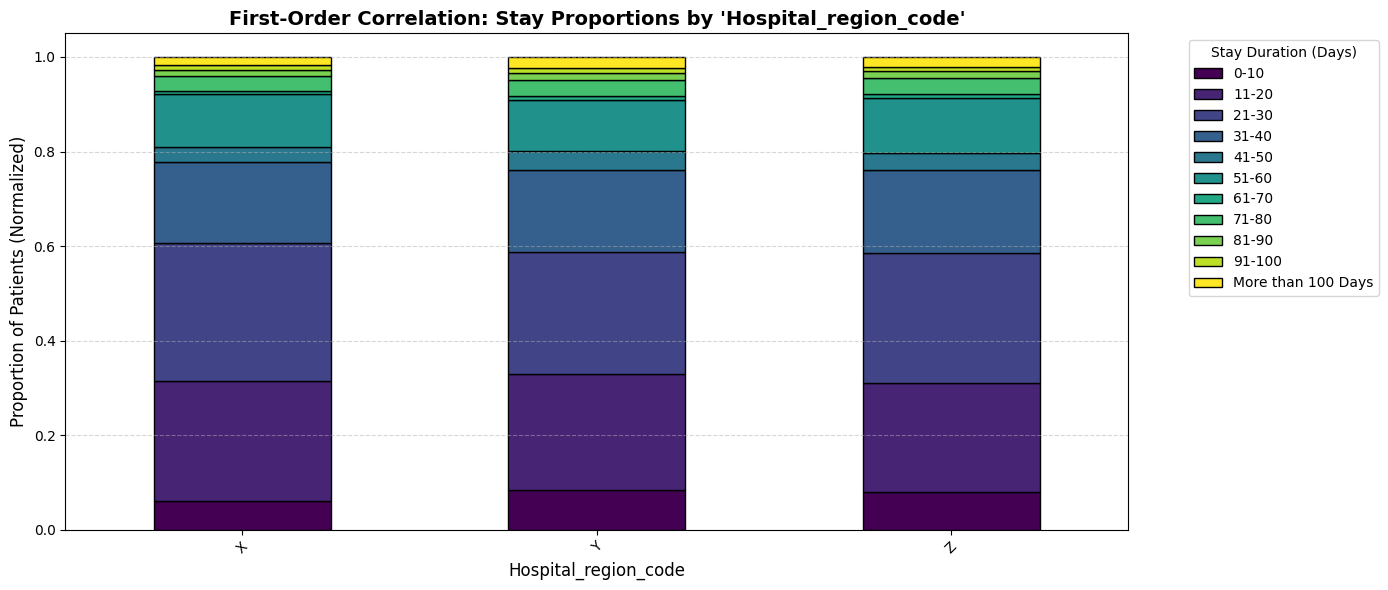


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Hospital_region_code'
Stay                  0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Hospital_region_code                                                                                          
X                     6.10  25.45  29.14  17.08   3.29  11.02   0.75   3.07   1.43    0.86                1.80
Y                     8.53  24.35  25.83  17.41   4.10  10.62   0.97   3.32   1.58    0.87                2.42
Z                     7.98  23.12  27.35  17.59   3.67  11.61   0.87   3.32   1.57    0.87                2.04



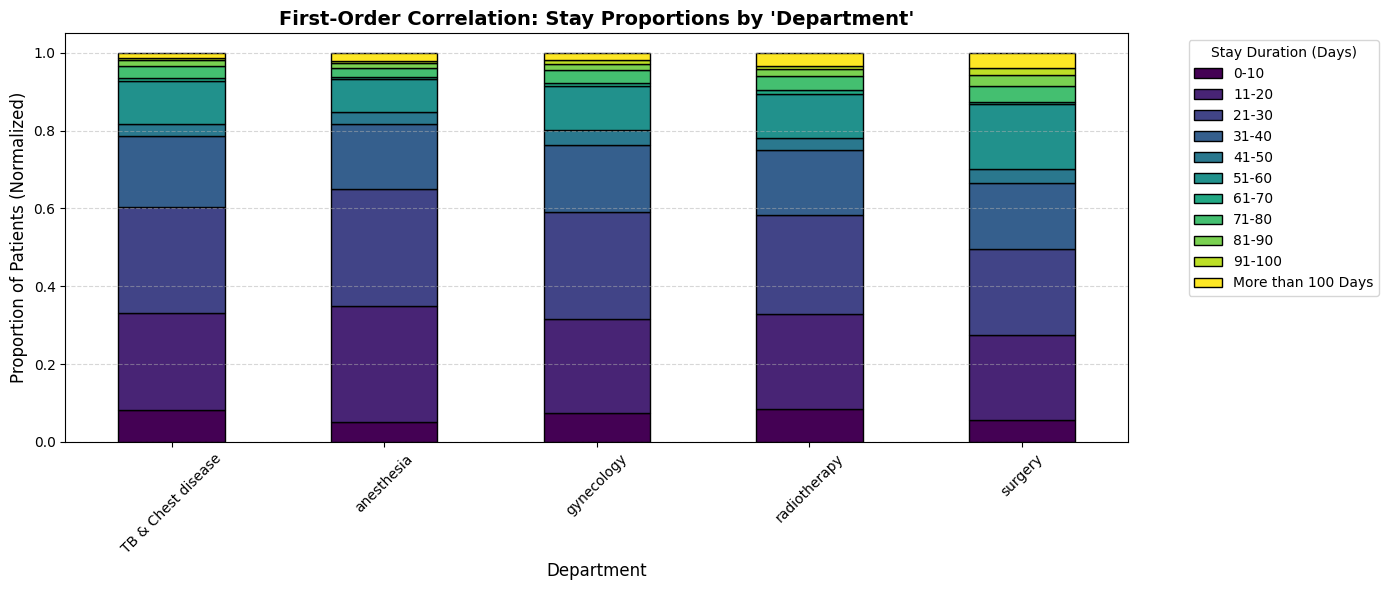


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Department'
Stay                0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Department                                                                                                  
TB & Chest disease  8.22  24.83  27.28  18.35   3.11  10.90   0.78   3.07   1.48    0.67                1.31
anesthesia          5.13  29.74  30.21  16.74   2.86   8.49   0.58   2.38   1.29    0.53                2.05
gynecology          7.55  23.96  27.45  17.43   3.87  11.21   0.89   3.27   1.50    0.91                1.98
radiotherapy        8.35  24.56  25.49  16.51   3.07  11.41   0.92   3.66   1.86    0.89                3.29
surgery             5.60  21.96  21.96  17.06   3.59  16.62   0.44   4.11   3.06    1.75                3.85



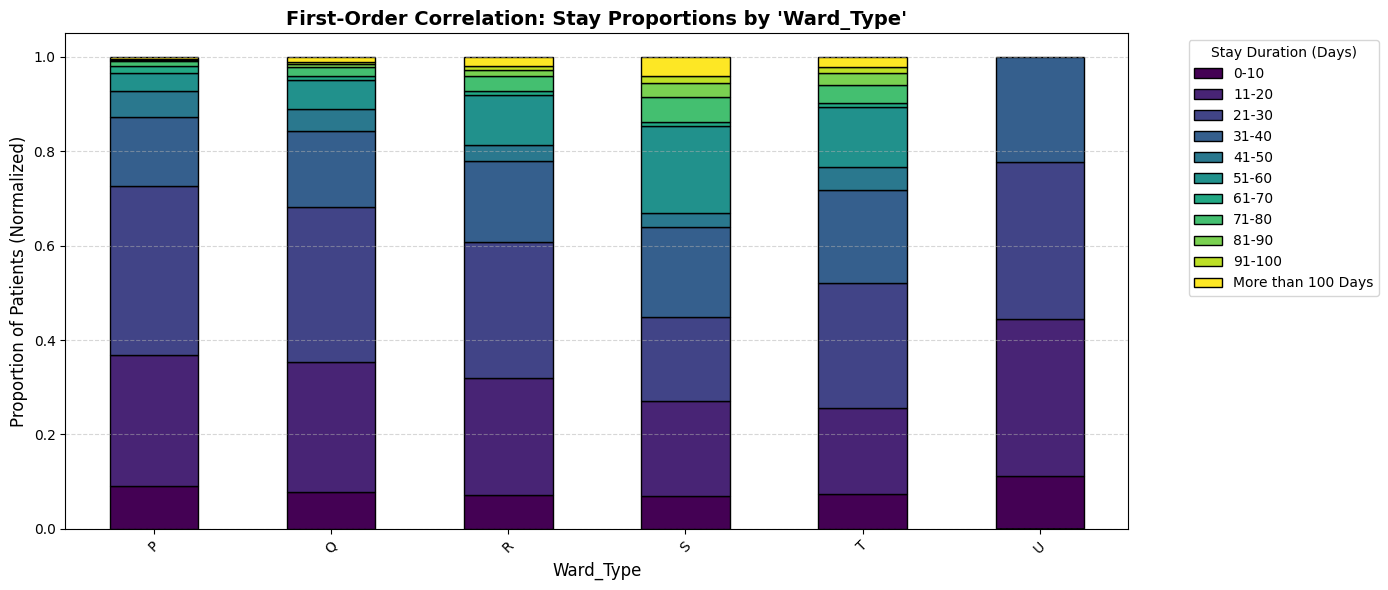


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Ward_Type'
Stay        0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Ward_Type                                                                                           
P           9.13  27.68  35.79  14.59   5.66   3.72   1.48   1.01   0.28    0.32                0.34
Q           7.85  27.56  32.75  16.17   4.64   6.07   0.93   1.84   0.74    0.43                1.01
R           7.26  24.74  28.74  17.21   3.33  10.72   0.81   3.13   1.32    0.87                1.87
S           6.94  20.14  17.83  19.16   2.79  18.53   0.80   5.37   2.95    1.47                4.02
T           7.44  18.16  26.55  19.73   4.71  12.76   0.89   3.75   2.59    1.37                2.05
U          11.11  33.33  33.33  22.22   0.00   0.00   0.00   0.00   0.00    0.00                0.00



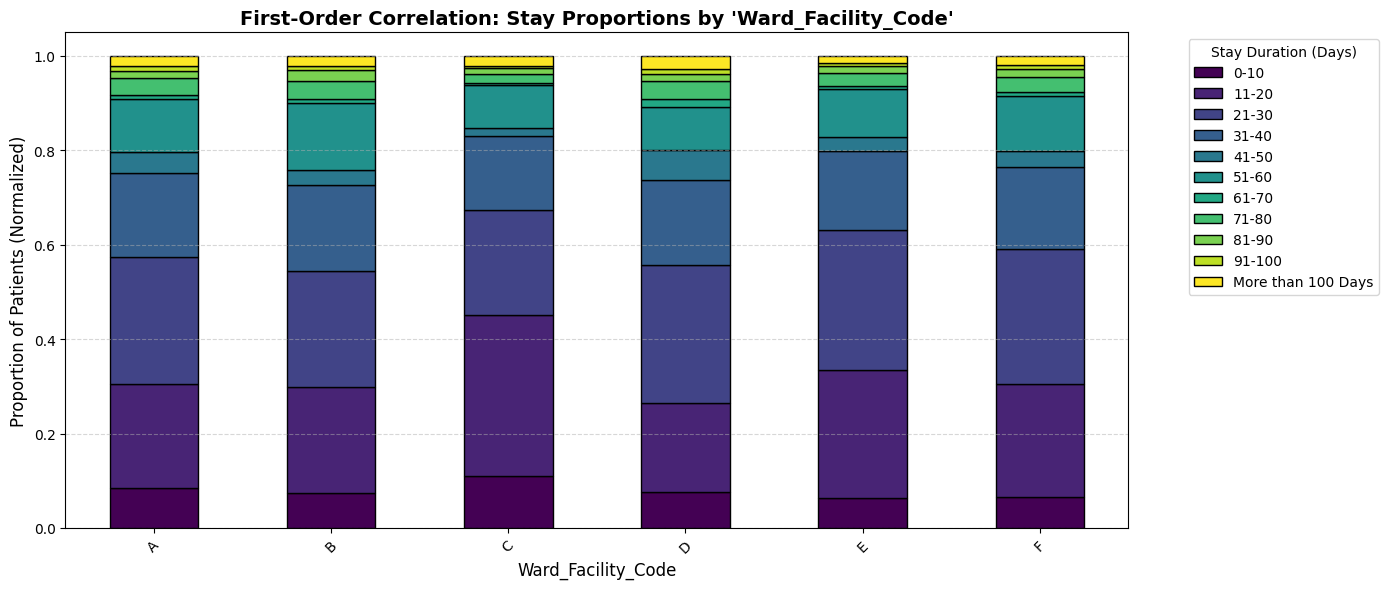


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Ward_Facility_Code'
Stay                 0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Ward_Facility_Code                                                                                           
A                    8.51  21.99  26.86  17.92   4.29  11.32   0.91   3.46   1.47    1.03                2.24
B                    7.39  22.42  24.57  18.23   3.12  14.40   0.71   3.92   2.18    0.95                2.10
C                   11.07  34.03  22.19  15.79   1.67   9.05   0.39   2.03   1.13    0.44                2.21
D                    7.55  19.02  29.17  17.96   6.44   9.13   1.54   3.81   1.49    1.10                2.78
E                    6.28  27.29  29.66  16.59   3.07  10.09   0.75   2.73   1.32    0.70                1.52
F                    6.47  24.12  28.45  17.40   3.36  11.73   0.78   3.28   1.55    0.90                1.96



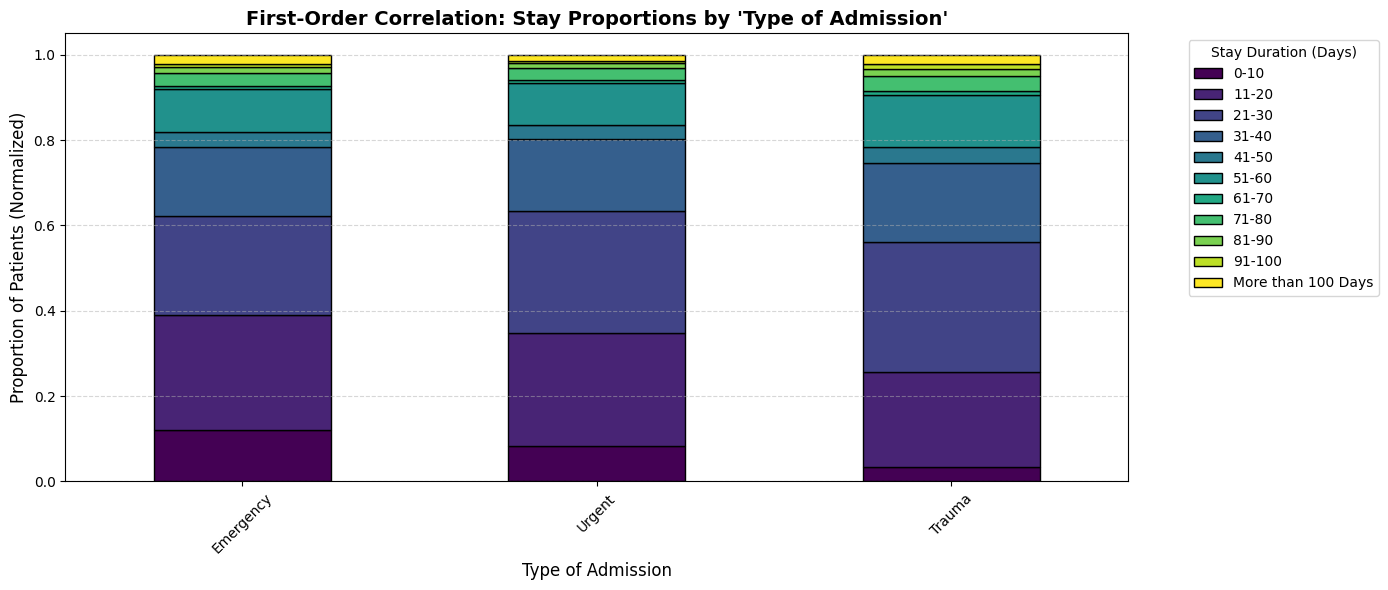


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Type of Admission'
Stay                0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Type of Admission                                                                                           
Emergency          12.11  26.91  23.28  16.05   3.50  10.07   0.82   2.85   1.45    0.79                2.16
Urgent              8.36  26.45  28.57  16.78   3.37   9.94   0.60   2.74   1.19    0.64                1.37
Trauma              3.49  22.17  30.42  18.45   3.91  12.01   0.97   3.65   1.67    0.99                2.26



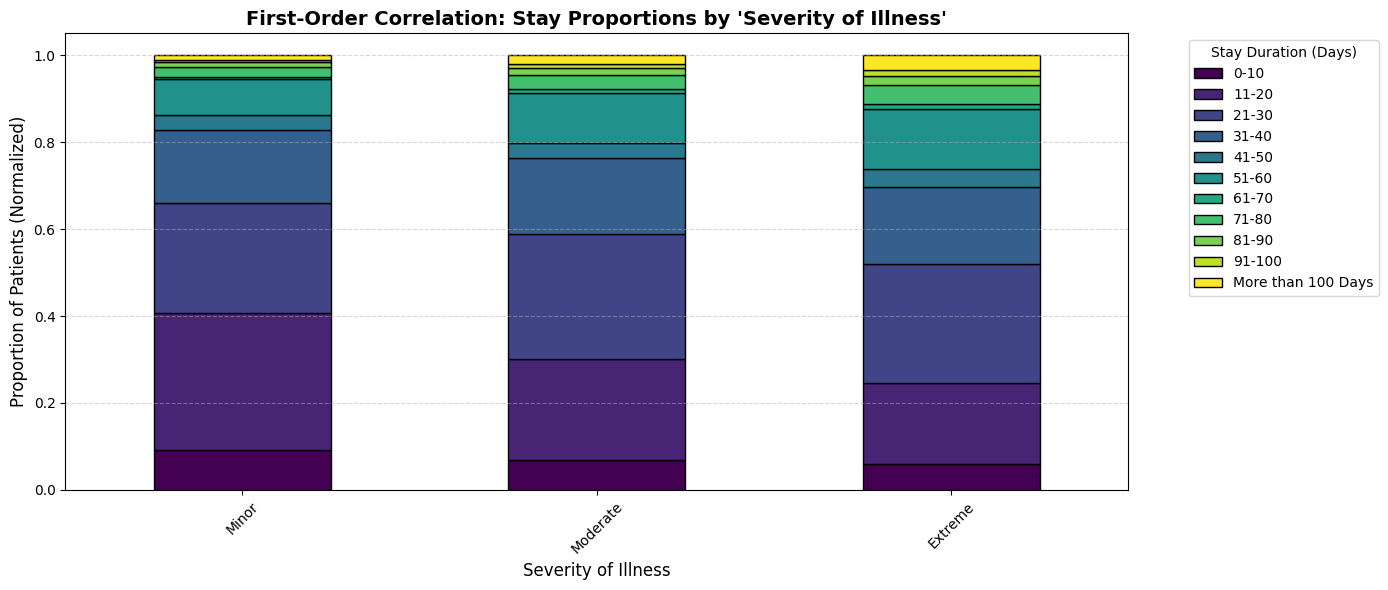


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Severity of Illness'
Stay                 0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Severity of Illness                                                                                          
Minor                9.19  31.62  25.11  16.76   3.48   8.27   0.60   2.23   1.14    0.50                1.10
Moderate             7.00  23.08  28.72  17.42   3.62  11.43   0.90   3.27   1.56    0.87                2.13
Extreme              5.99  18.56  27.35  17.79   4.14  13.70   1.14   4.54   1.96    1.41                3.42



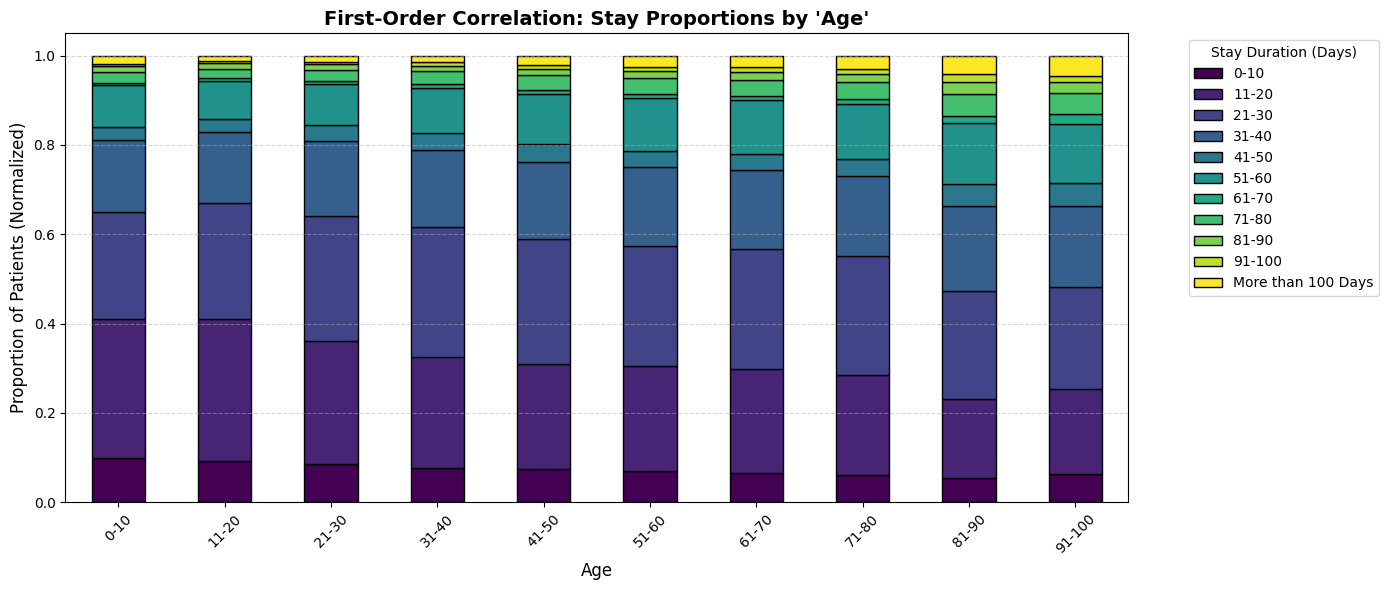


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Age'
Stay    0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Age                                                                                             
0-10    9.79  31.34  23.83  16.16   2.99   9.31   0.42   2.47   1.36    0.57                1.78
11-20   9.25  31.88  25.78  15.92   3.05   8.54   0.53   2.09   1.32    0.42                1.24
21-30   8.46  27.60  27.97  16.93   3.42   9.24   0.64   2.51   1.34    0.56                1.33
31-40   7.72  24.85  29.17  17.14   3.72  10.23   0.79   2.85   1.25    0.76                1.53
41-50   7.41  23.49  28.15  17.23   3.91  11.29   0.88   3.34   1.38    0.90                2.02
51-60   7.08  23.45  26.94  17.61   3.56  11.81   0.93   3.52   1.61    1.02                2.47
61-70   6.53  23.39  26.82  17.59   3.59  12.09   0.97   3.66   1.78    0.98                2.61
71-80   6.16  22.25  26.63  17.95   3.85  12.35   1.05   3.

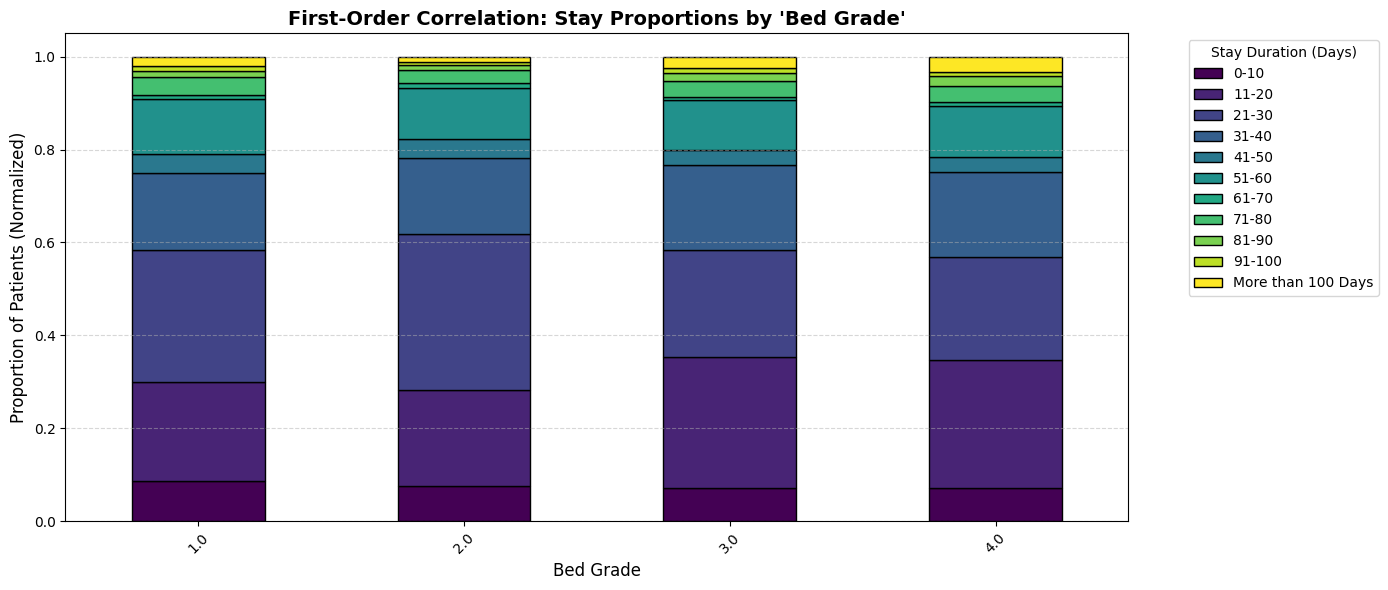


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Bed Grade'
Stay       0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Bed Grade                                                                                          
1.0        8.74  21.21  28.42  16.63   4.07  11.70   1.03   3.76   1.35    1.05                2.04
2.0        7.52  20.64  33.67  16.27   4.14  11.08   0.92   2.87   1.00    0.74                1.14
3.0        7.12  28.18  23.14  18.19   3.29  10.72   0.75   3.29   1.85    0.91                2.56
4.0        7.12  27.68  22.16  18.16   3.25  10.93   0.85   3.56   2.07    0.95                3.25

🔄 Starting batch generation for 5 second-order matrices...



/tmp/ipykernel_27901/160713656.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


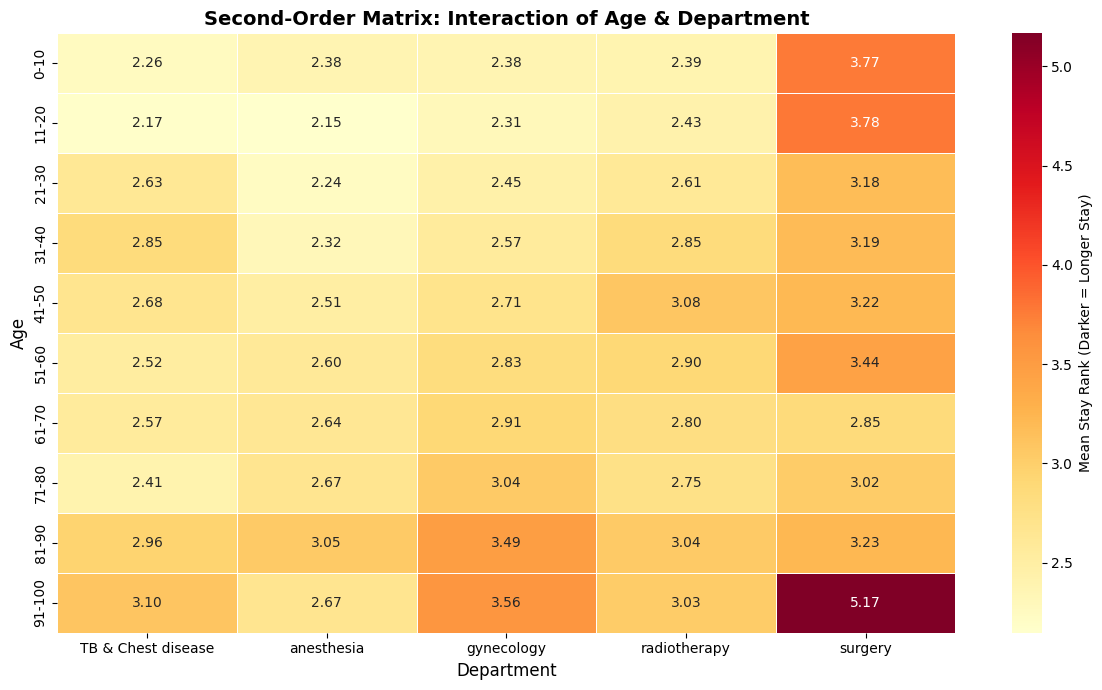


STATISTICAL MATRIX: Mean Stay Rank for 'Age' combined with 'Department'
Note: Ranks range from 0 (0-10 Days) to 10 (More than 100 Days).
Department  TB & Chest disease  anesthesia  gynecology  radiotherapy  surgery
Age                                                                          
0-10                      2.26        2.38        2.38          2.39     3.77
11-20                     2.17        2.15        2.31          2.43     3.78
21-30                     2.63        2.24        2.45          2.61     3.18
31-40                     2.85        2.32        2.57          2.85     3.19
41-50                     2.68        2.51        2.71          3.08     3.22
51-60                     2.52        2.60        2.83          2.90     3.44
61-70                     2.57        2.64        2.91          2.80     2.85
71-80                     2.41        2.67        3.04          2.75     3.02
81-90                     2.96        3.05        3.49          3.04     3.23
91-1

/tmp/ipykernel_27901/160713656.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


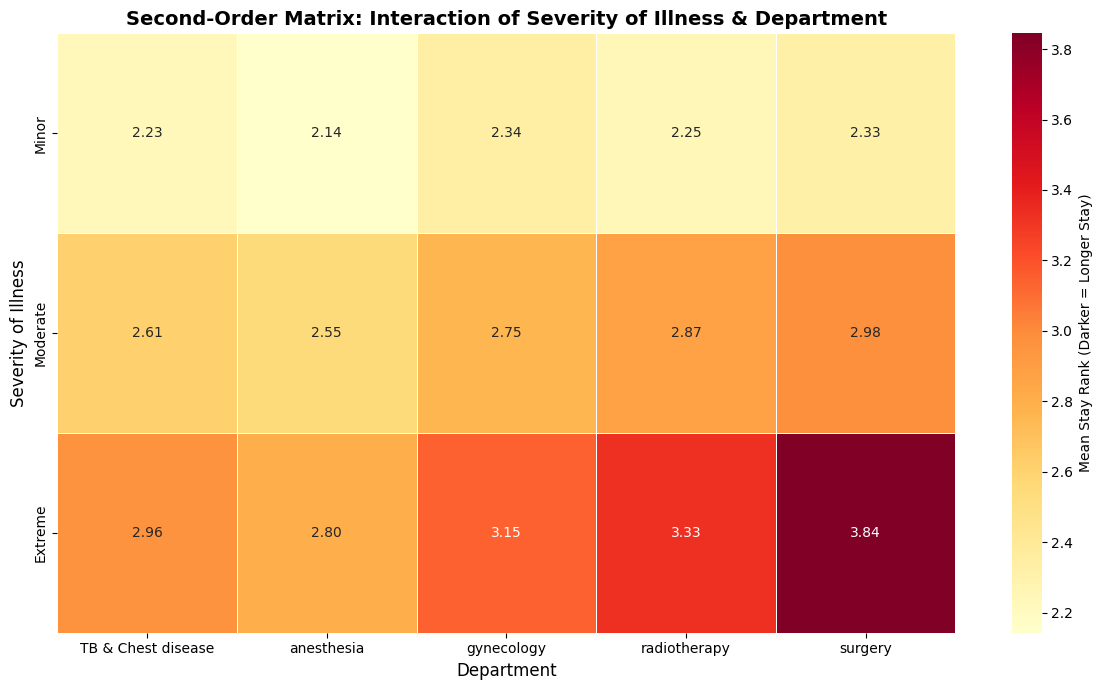


STATISTICAL MATRIX: Mean Stay Rank for 'Severity of Illness' combined with 'Department'
Note: Ranks range from 0 (0-10 Days) to 10 (More than 100 Days).
Department           TB & Chest disease  anesthesia  gynecology  radiotherapy  surgery
Severity of Illness                                                                   
Minor                              2.23        2.14        2.34          2.25     2.33
Moderate                           2.61        2.55        2.75          2.87     2.98
Extreme                            2.96        2.80        3.15          3.33     3.84



/tmp/ipykernel_27901/160713656.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


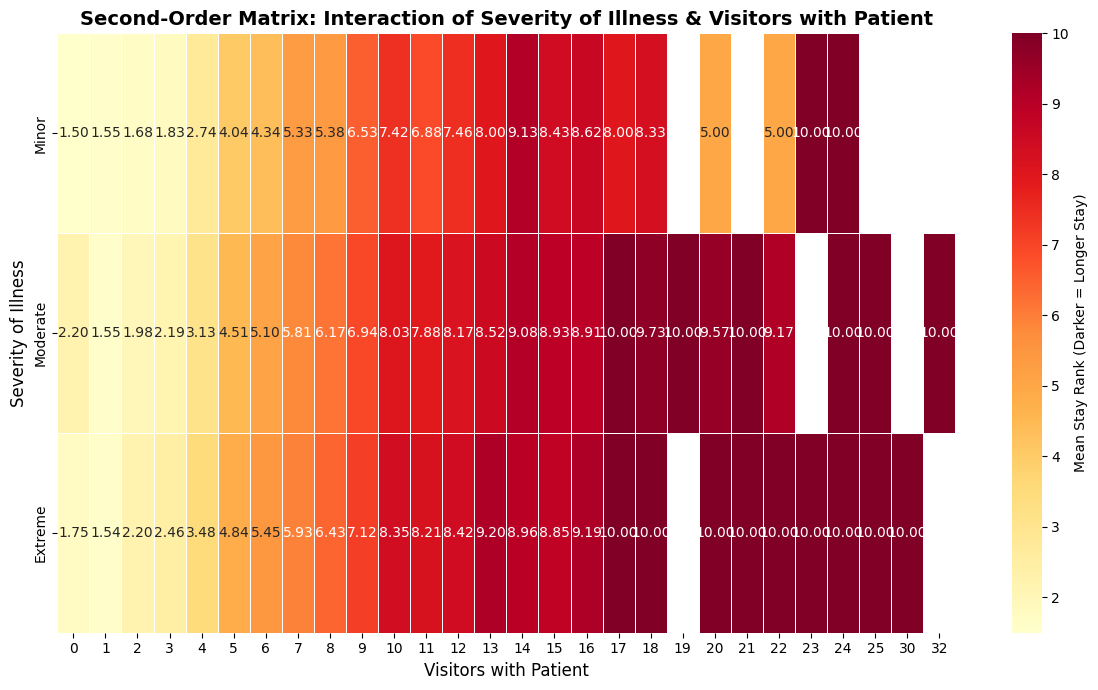


STATISTICAL MATRIX: Mean Stay Rank for 'Severity of Illness' combined with 'Visitors with Patient'
Note: Ranks range from 0 (0-10 Days) to 10 (More than 100 Days).
Visitors with Patient    0     1     2     3     4     5     6     7     8     9     10    11    12    13    14    15    16    17     18    19     20    21     22    23    24    25    30    32
Severity of Illness                                                                                                                                                                             
Minor                  1.50  1.55  1.68  1.83  2.74  4.04  4.34  5.33  5.38  6.53  7.42  6.88  7.46  8.00  9.13  8.43  8.62   8.0   8.33   NaN   5.00   NaN   5.00  10.0  10.0   NaN   NaN   NaN
Moderate               2.20  1.55  1.98  2.19  3.13  4.51  5.10  5.81  6.17  6.94  8.03  7.88  8.17  8.52  9.08  8.93  8.91  10.0   9.73  10.0   9.57  10.0   9.17   NaN  10.0  10.0   NaN  10.0
Extreme                1.75  1.54  2.20  2.46  3.48  4.84  5.45

/tmp/ipykernel_27901/160713656.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


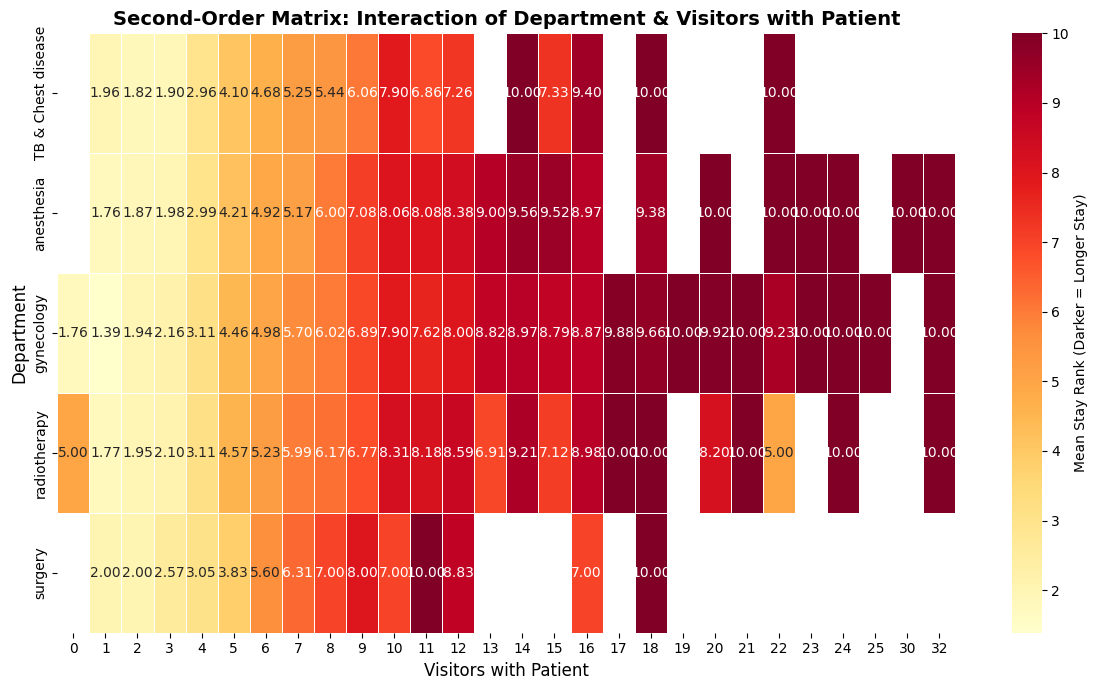


STATISTICAL MATRIX: Mean Stay Rank for 'Department' combined with 'Visitors with Patient'
Note: Ranks range from 0 (0-10 Days) to 10 (More than 100 Days).
Visitors with Patient    0     1     2     3     4     5     6     7     8     9     10     11    12    13     14    15    16     17     18    19     20    21     22    23    24    25    30    32
Department                                                                                                                                                                                         
TB & Chest disease      NaN  1.96  1.82  1.90  2.96  4.10  4.68  5.25  5.44  6.06  7.90   6.86  7.26   NaN  10.00  7.33  9.40    NaN  10.00   NaN    NaN   NaN  10.00   NaN   NaN   NaN   NaN   NaN
anesthesia              NaN  1.76  1.87  1.98  2.99  4.21  4.92  5.17  6.00  7.08  8.06   8.08  8.38  9.00   9.56  9.52  8.97    NaN   9.38   NaN  10.00   NaN  10.00  10.0  10.0   NaN  10.0  10.0
gynecology             1.76  1.39  1.94  2.16  3.11  4.46  4

/tmp/ipykernel_27901/160713656.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


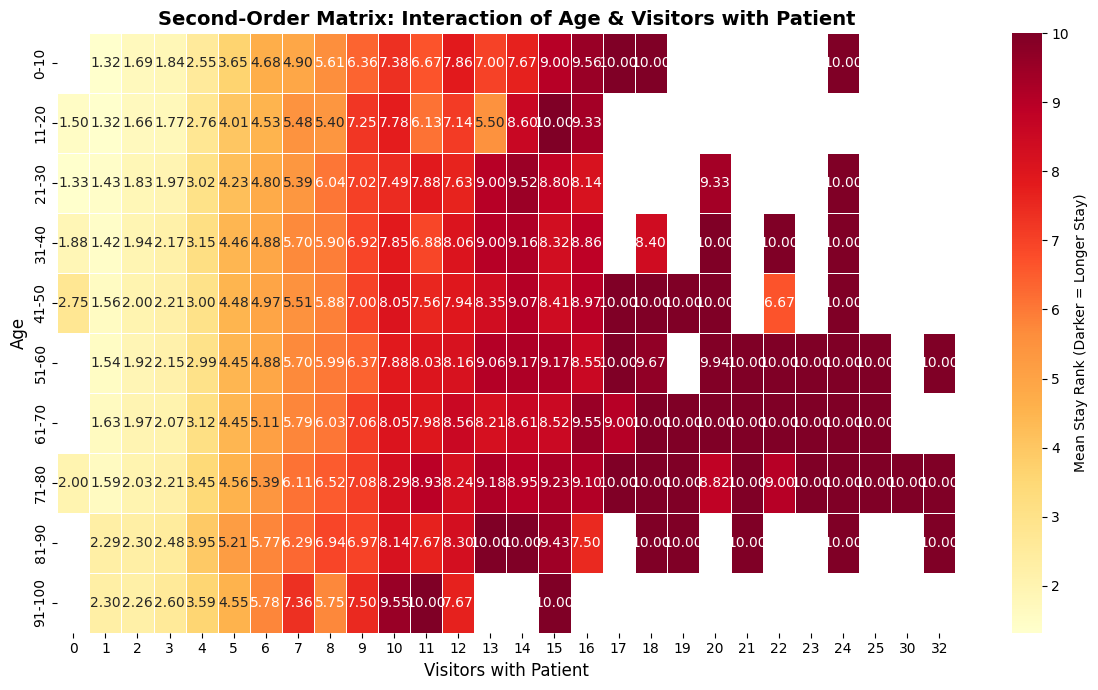


STATISTICAL MATRIX: Mean Stay Rank for 'Age' combined with 'Visitors with Patient'
Note: Ranks range from 0 (0-10 Days) to 10 (More than 100 Days).
Visitors with Patient    0     1     2     3     4     5     6     7     8     9     10     11    12     13     14     15    16    17     18    19     20    21     22    23    24    25    30    32
Age                                                                                                                                                                                                 
0-10                    NaN  1.32  1.69  1.84  2.55  3.65  4.68  4.90  5.61  6.36  7.38   6.67  7.86   7.00   7.67   9.00  9.56  10.0  10.00   NaN    NaN   NaN    NaN   NaN  10.0   NaN   NaN   NaN
11-20                  1.50  1.32  1.66  1.77  2.76  4.01  4.53  5.48  5.40  7.25  7.78   6.13  7.14   5.50   8.60  10.00  9.33   NaN    NaN   NaN    NaN   NaN    NaN   NaN   NaN   NaN   NaN   NaN
21-30                  1.33  1.43  1.83  1.97  3.02  4.23  4.80

In [31]:
# ==============================================================================
# CELL 3: AUTOMATED BATCH PROCESSING LOOPS
# ==============================================================================

# Defensive check: Ensure Cell 2 engines are loaded [Certain]
if 'render_first_order_plot' not in globals():
    raise RuntimeError("❌ Rendering engines missing. You must run Cell 2 first.")

def generate_all_first_order_plots(dataframe):
    """
    Automatically cycles through every categorical feature and generates
    its stacked bar chart using the Cell 2 engine.
    """
    print(f"🔄 Starting batch generation for {len(CATEGORICAL_FEATURES)} first-order plots...\n")
    for column in CATEGORICAL_FEATURES:
        # Calls the rendering engine from Cell 2
        render_first_order_plot(dataframe, column)

def generate_strategic_second_order_heatmaps(dataframe):
    """
    Automatically generates heatmaps for specific strategic metric combinations.
    """
    # These are the specific pairs your team identified as operationally important
    strategic_combinations = [
        ('Age', 'Department'),
        ('Severity of Illness', 'Department'),
        ('Severity of Illness', 'Visitors with Patient'),
        ('Department', 'Visitors with Patient'),
        ('Age', 'Visitors with Patient')
    ]

    print(f"🔄 Starting batch generation for {len(strategic_combinations)} second-order matrices...\n")
    for metric_a, metric_b in strategic_combinations:
        # Calls the rendering engine from Cell 2
        render_second_order_heatmap(dataframe, metric_a, metric_b)

# ==============================================================================
# EXECUTION COMMANDS
# ==============================================================================
# Uncomment (remove the #) from the lines below if you want to print all the charts at once.
# Otherwise, leave them commented out so the cell just loads the functions quietly.

#generate_all_first_order_plots(df)
#generate_strategic_second_order_heatmaps(df)

print("Batch processing loops loaded. Ready for automated generation.")

      HEALTHCARE DATA VISUALIZATION MENU          
[0] Hospital_type_code
[1] Hospital_region_code
[2] Department
[3] Ward_Type
[4] Ward_Facility_Code
[5] Type of Admission
[6] Severity of Illness
[7] Age
[8] Bed Grade
[9] Admission_Deposit
[10] Visitors with Patient
[11] Available Extra Rooms in Hospital
Enter the NUMBER for Variable A: 2
Enter the NUMBER for Variable B: 6

🔄 Generating interaction matrix for: Department x Severity of Illness...



/tmp/ipykernel_27901/160713656.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = dataframe.groupby([metric_a, metric_b])['Stay_Numeric_Rank'].mean().unstack()


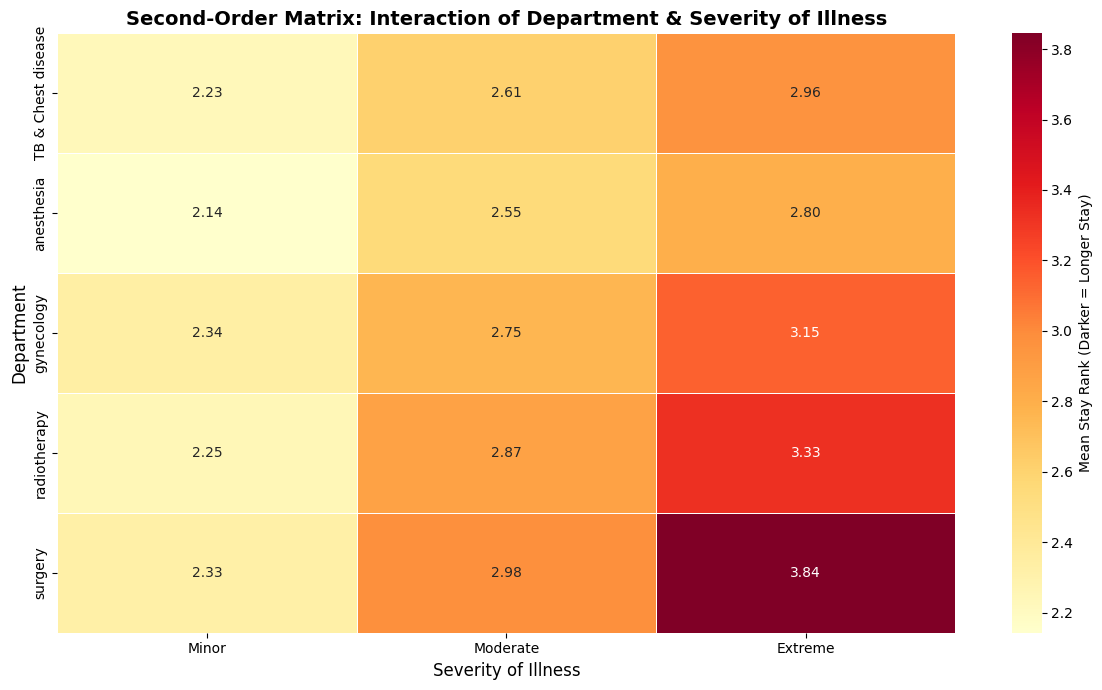


STATISTICAL MATRIX: Mean Stay Rank for 'Department' combined with 'Severity of Illness'
Note: Ranks range from 0 (0-10 Days) to 10 (More than 100 Days).
Severity of Illness  Minor  Moderate  Extreme
Department                                   
TB & Chest disease    2.23      2.61     2.96
anesthesia            2.14      2.55     2.80
gynecology            2.34      2.75     3.15
radiotherapy          2.25      2.87     3.33
surgery               2.33      2.98     3.84



In [32]:
# ==============================================================================
# CELL 4: INTERACTIVE SECOND-ORDER VISUALIZATION CONTROLLER
# ==============================================================================

# Defensive check: Ensure Cell 2 engines are loaded [Certain]
if 'render_second_order_heatmap' not in globals():
    raise RuntimeError("❌ Rendering engines missing. You must run Cell 2 first.")

def interactive_correlation_controller(dataframe):
    """
    Launches an interactive menu in the console allowing the user to select
    two variables and instantly renders their second-order heatmap using the Cell 2 engine.
    """
    # Dynamically combine our global lists from Cell 1 so we never have to re-type them [Certain]
    all_available_metrics = CATEGORICAL_FEATURES + CONTINUOUS_FEATURES

    print("==================================================")
    print("      HEALTHCARE DATA VISUALIZATION MENU          ")
    print("==================================================")
    for index, metric in enumerate(all_available_metrics):
        print(f"[{index}] {metric}")
    print("==================================================")

    # --- GET SELECTION FOR VARIABLE A ---
    try:
        selection_a = int(input("Enter the NUMBER for Variable A: "))
        if selection_a not in range(len(all_available_metrics)):
            print("❌ Invalid selection. Run the cell again.")
            return
    except ValueError:
        print("❌ Error: You must enter an integer number.")
        return

    # --- GET SELECTION FOR VARIABLE B ---
    try:
        selection_b = int(input("Enter the NUMBER for Variable B: "))
        if selection_b not in range(len(all_available_metrics)):
            print("❌ Invalid selection. Run the cell again.")
            return
    except ValueError:
        print("❌ Error: You must enter an integer number.")
        return

    # Extract the exact string names based on user input
    metric_a = all_available_metrics[selection_a]
    metric_b = all_available_metrics[selection_b]

    print(f"\n🔄 Generating interaction matrix for: {metric_a} x {metric_b}...\n")

    # DELEGATION: Call the exact rendering engine from Cell 2 instead of re-writing plot code! [Certain]
    render_second_order_heatmap(dataframe, metric_a, metric_b)

# Run the controller
interactive_correlation_controller(df)

     SELECT A METRIC TO VISUALIZE FIRST-ORDER     
[0] Hospital_type_code
[1] Hospital_region_code
[2] Department
[3] Ward_Type
[4] Ward_Facility_Code
[5] Type of Admission
[6] Severity of Illness
[7] Age
[8] Bed Grade
[9] Admission_Deposit
[10] Visitors with Patient
[11] Available Extra Rooms in Hospital
Enter the NUMBER of the column you want to visualize: 2

🔄 Delegating first-order generation for: 'Department'...



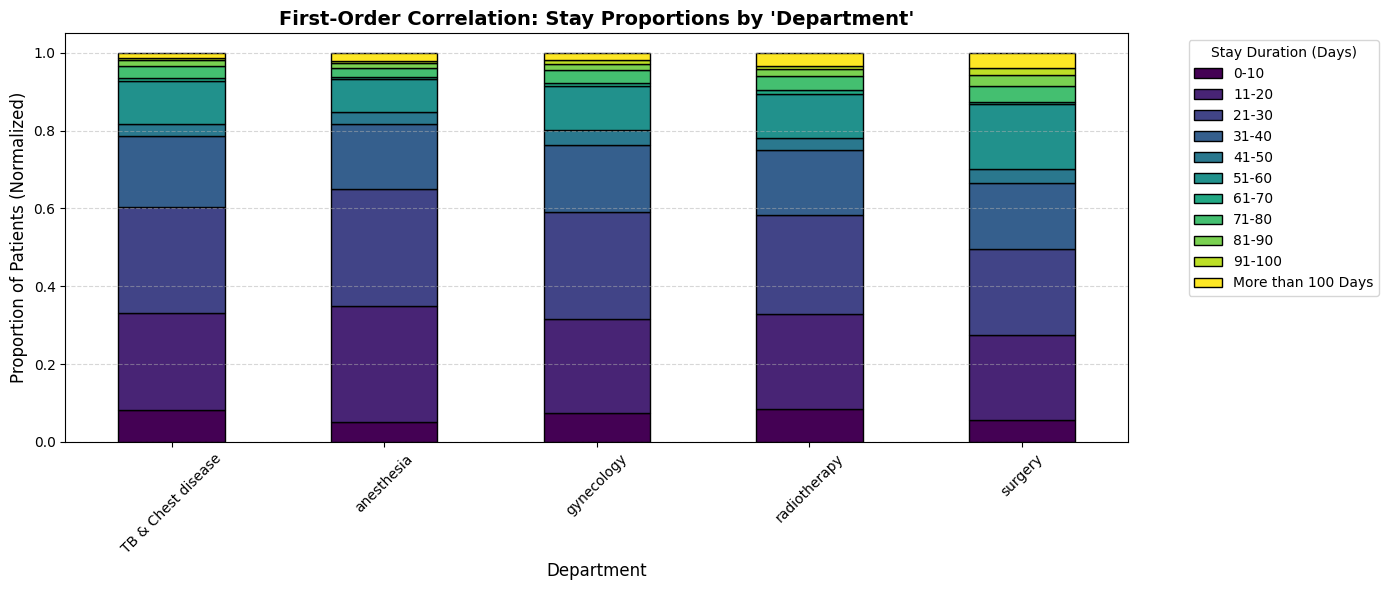


STATISTICAL MATRIX: Likelihood (%) of Stay Duration based on 'Department'
Stay                0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  More than 100 Days
Department                                                                                                  
TB & Chest disease  8.22  24.83  27.28  18.35   3.11  10.90   0.78   3.07   1.48    0.67                1.31
anesthesia          5.13  29.74  30.21  16.74   2.86   8.49   0.58   2.38   1.29    0.53                2.05
gynecology          7.55  23.96  27.45  17.43   3.87  11.21   0.89   3.27   1.50    0.91                1.98
radiotherapy        8.35  24.56  25.49  16.51   3.07  11.41   0.92   3.66   1.86    0.89                3.29
surgery             5.60  21.96  21.96  17.06   3.59  16.62   0.44   4.11   3.06    1.75                3.85



In [33]:
# ==============================================================================
# CELL 5: UNIVERSAL FIRST-ORDER CONTROLLER
# ==============================================================================

# Defensive check: Ensure Cell 2 engines are loaded [Certain]
if 'render_first_order_plot' not in globals():
    raise RuntimeError("❌ Rendering engines missing. You must run Cell 2 first.")

def universal_first_order_controller(dataframe):
    """
    Interactive console menu for First-Order Stacked Bar Charts.
    Delegates all mathematical binning and plotting to the Cell 2 engine.
    """
    # Combine global lists to dynamically generate the menu options [Certain]
    all_available_metrics = CATEGORICAL_FEATURES + CONTINUOUS_FEATURES

    print("==================================================")
    print("     SELECT A METRIC TO VISUALIZE FIRST-ORDER     ")
    print("==================================================")
    for index, column in enumerate(all_available_metrics):
        print(f"[{index}] {column}")
    print("==================================================")

    # --- ACQUIRE USER SELECTION ---
    try:
        user_choice = int(input("Enter the NUMBER of the column you want to visualize: "))
        if user_choice not in range(len(all_available_metrics)):
            print("❌ Invalid entry. Please run the cell again.")
            return
    except ValueError:
        print("❌ Error: Input must be a valid integer number.")
        return

    selected_column = all_available_metrics[user_choice]
    print(f"\n🔄 Delegating first-order generation for: '{selected_column}'...\n")

    # --- DELEGATION ---
    # The controller does no heavy lifting. It calls the Cell 2 engine. [Certain]
    render_first_order_plot(dataframe, selected_column)

# Run the controller
universal_first_order_controller(df)

   SELECT A CONTINUOUS METRIC FOR TREND ANALYSIS  
[0] Admission_Deposit
[1] Visitors with Patient
[2] Available Extra Rooms in Hospital
Enter NUMBER of the continuous metric to analyze: 0

🔄 Delegating trend line generation for: 'Admission_Deposit'...



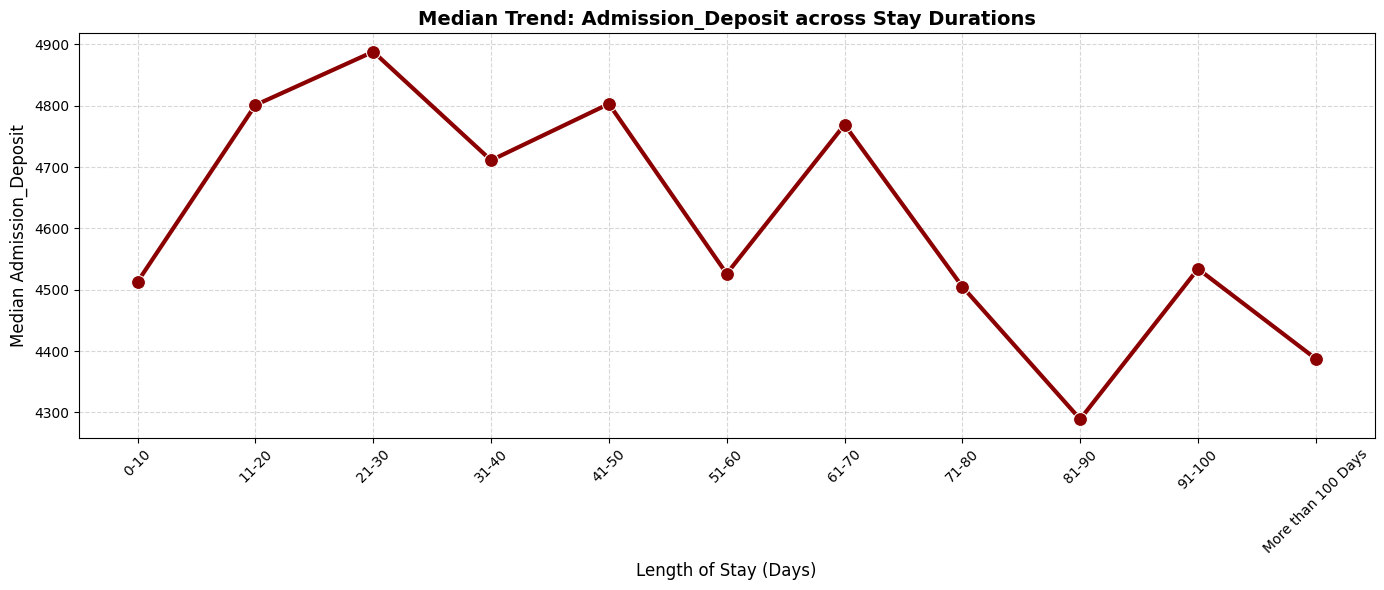


STATISTICAL MATRIX: Exact Median 'Admission_Deposit' for each Stay category
              Stay  Admission_Deposit
              0-10             4513.0
             11-20             4801.0
             21-30             4888.0
             31-40             4711.0
             41-50             4803.0
             51-60             4526.0
             61-70             4769.0
             71-80             4505.0
             81-90             4289.0
            91-100             4534.0
More than 100 Days             4387.5



/tmp/ipykernel_27901/160713656.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_df = dataframe.groupby(TARGET_VAR)[continuous_metric].median().reset_index()


In [34]:
# ==============================================================================
# CELL 6: CONTINUOUS METRICS - MEDIAN TREND LINE CONTROLLER
# ==============================================================================

# Defensive check: Ensure Cell 2 engines are loaded [Certain]
if 'render_median_trendline' not in globals():
    raise RuntimeError("❌ Rendering engines missing. You must run Cell 2 first.")

def interactive_median_trend_controller(dataframe):
    """
    Interactive console menu for plotting the median trend of continuous variables.
    Delegates all plotting architecture to the Cell 2 engine.
    """
    print("==================================================")
    print("   SELECT A CONTINUOUS METRIC FOR TREND ANALYSIS  ")
    print("==================================================")
    # Dynamically generates the menu using the global list from Cell 1 [Certain]
    for index, column in enumerate(CONTINUOUS_FEATURES):
        print(f"[{index}] {column}")
    print("==================================================")

    # --- ACQUIRE USER SELECTION ---
    try:
        user_choice = int(input("Enter NUMBER of the continuous metric to analyze: "))
        if user_choice not in range(len(CONTINUOUS_FEATURES)):
            print("❌ Invalid entry. Please run the cell again.")
            return
    except ValueError:
        print("❌ Error: Input must be a valid integer number.")
        return

    selected_column = CONTINUOUS_FEATURES[user_choice]
    print(f"\n🔄 Delegating trend line generation for: '{selected_column}'...\n")

    # --- DELEGATION ---
    # Calls the central engine instead of rewriting sns.lineplot code [Certain]
    render_median_trendline(dataframe, selected_column)

# Run the controller
interactive_median_trend_controller(df)

      SELECT A METRIC FOR DEEP-DIVE ANALYSIS      
[0] Hospital_type_code
[1] Hospital_region_code
[2] Department
[3] Ward_Type
[4] Ward_Facility_Code
[5] Type of Admission
[6] Severity of Illness
[7] Age
[8] Bed Grade
Enter NUMBER for the Metric you want to analyze: 2

     SELECT A STAY DURATION (COLOR) TO ISOLATE    
[0] 0-10
[1] 11-20
[2] 21-30
[3] 31-40
[4] 41-50
[5] 51-60
[6] 61-70
[7] 71-80
[8] 81-90
[9] 91-100
[10] More than 100 Days
Enter NUMBER for the specific Stay Duration to isolate: 1

🔄 Isolating '11-20' within 'Department'...



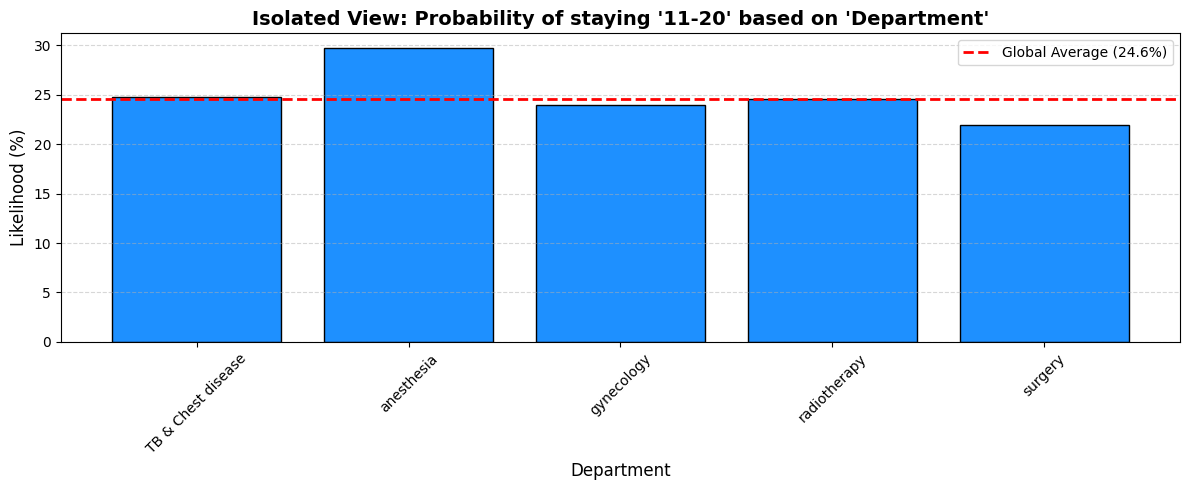


DETAILED STATISTICAL CONTEXT: '11-20' grouped by 'Department'
Baseline Global Probability: 24.57% of all patients stay this long.
                    Total Patients  Stayed 11-20 (Count)  Likelihood (%)  Shift from Baseline (%)
Department                                                                                       
TB & Chest disease            9460                  2349           24.83                     0.26
anesthesia                   29187                  8680           29.74                     5.17
gynecology                  245850                 58901           23.96                    -0.61
radiotherapy                 28153                  6914           24.56                    -0.01
surgery                       1143                   251           21.96                    -2.61



In [36]:
# ==============================================================================
# CELL 7: STATISTICAL DEEP-DIVE ISOLATOR
# ==============================================================================

# Defensive check: Ensure Cell 1 is loaded [Certain]
if 'CATEGORICAL_FEATURES' not in globals():
    raise RuntimeError("❌ Global features missing. You must run Cell 1 first.")

def isolated_first_order_deep_dive(dataframe):
    """
    Allows the user to visually isolate a single stay category to eliminate
    baseline shifting, and generates a detailed statistical matrix for context.
    """
    print("==================================================")
    print("      SELECT A METRIC FOR DEEP-DIVE ANALYSIS      ")
    print("==================================================")
    # Dynamically loads the categorical options from Cell 1 memory [Certain]
    for index, column in enumerate(CATEGORICAL_FEATURES):
        print(f"[{index}] {column}")
    print("==================================================")

    # --- GET INDEPENDENT VARIABLE ---
    try:
        var_choice = int(input("Enter NUMBER for the Metric you want to analyze: "))
        selected_metric = CATEGORICAL_FEATURES[var_choice]
    except (ValueError, IndexError):
        print("❌ Invalid entry. Please run the cell again.")
        return

    # --- GET TARGET STAY DURATION ---
    # Dynamically pulls the stay categories straight from the dataframe [Certain]
    stay_categories = dataframe[TARGET_VAR].cat.categories.tolist()
    print("\n==================================================")
    print("     SELECT A STAY DURATION (COLOR) TO ISOLATE    ")
    print("==================================================")
    for index, stay in enumerate(stay_categories):
        print(f"[{index}] {stay}")
    print("==================================================")

    try:
        stay_choice = int(input(f"Enter NUMBER for the specific {TARGET_VAR} Duration to isolate: "))
        selected_stay = stay_categories[stay_choice]
    except (ValueError, IndexError):
        print("❌ Invalid entry. Please run the cell again.")
        return

    print(f"\n🔄 Isolating '{selected_stay}' within '{selected_metric}'...\n")

    # --- MATH & STATS CALCULATION ---
    # 1. Find the global average probability of this stay happening at all
    global_prob = (len(dataframe[dataframe[TARGET_VAR] == selected_stay]) / len(dataframe)) * 100

    # 2. Build the exact counts and percentage matrix for the selected metric [Certain]
    crosstab_counts = pd.crosstab(dataframe[selected_metric], dataframe[TARGET_VAR])
    crosstab_percentages = crosstab_counts.div(crosstab_counts.sum(1), axis=0) * 100

    # Extract just the column we care about
    isolated_percentages = crosstab_percentages[selected_stay]

    # --- RENDER ISOLATED VISUAL ---
    plt.figure(figsize=(12, 5))

    # Because it is only one variable, it sits flat on the X-axis. No visual shifting. [Certain]
    bars = plt.bar(isolated_percentages.index.astype(str), isolated_percentages.values, color='dodgerblue', edgecolor='black')

    # Draw a red line showing the baseline global average
    plt.axhline(global_prob, color='red', linestyle='--', linewidth=2, label=f'Global Average ({global_prob:.1f}%)')

    plt.title(f"Isolated View: Probability of staying '{selected_stay}' based on '{selected_metric}'", fontsize=14, fontweight='bold')
    plt.ylabel(f"Likelihood (%)", fontsize=12)
    plt.xlabel(selected_metric, fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- PRINT DETAILED NUMERICAL CONTEXT ---
    print("\n" + "="*70)
    print(f"DETAILED STATISTICAL CONTEXT: '{selected_stay}' grouped by '{selected_metric}'")
    print(f"Baseline Global Probability: {global_prob:.2f}% of all patients stay this long.")
    print("="*70)

    # Build a clean output table
    stats_df = pd.DataFrame({
        'Total Patients': crosstab_counts.sum(axis=1),
        f'Stayed {selected_stay} (Count)': crosstab_counts[selected_stay],
        'Likelihood (%)': isolated_percentages.round(2),
        'Shift from Baseline (%)': (isolated_percentages - global_prob).round(2)
    })

    print(stats_df.to_string())
    print("="*70 + "\n")

# Run the deep dive controller
isolated_first_order_deep_dive(df)